# Chapter 4 — Evaluation Notebook: Gemini 2.5 Flash

**Thesis:** Assurance-Oriented RAG Framework for ISO/IEC 27001 and ITGC Audit  
**Model:** `gemini-2.5-flash` (Google Gemini 2.5 Flash — stable release)  
**Purpose:** Run all 20 ITGC-grounded questions through the RAG pipeline using Gemini 2.5 Flash,
collect responses, and evaluate with RAGAS (quantitative) and manual rubric (qualitative).

**Assumes** you already have from Notebook1:
- `document_store_fixed.json`
- `faiss_index.bin` + `bm25_corpus.pkl`
- `.env` file with your `GEMINI_API_KEY`

---
```
[20 ITGC Questions]  →  [RAG Pipeline]  →  [Gemini 2.5 Flash]  →  [Responses]
                                                                         ↓
                                         [RAGAS Auto-Scores]  +  [Manual Rubric]
                                                                         ↓
                                     [Chapter 4 Results DataFrame + CSV]
```

## Cell 1 — Install dependencies

In [1]:
!pip install google-generativeai langchain-google-genai ragas datasets langchain sentence-transformers faiss-cpu rank-bm25 pandas python-dotenv tqdm -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Load environment and configure paths

Add this to your `.env` file:
```
GEMINI_API_KEY=your-key-here
```
Get your key from https://aistudio.google.com/apikey (free tier available).

In [2]:
import os, json, time, pickle
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = "Enter Your API Key"
assert GEMINI_API_KEY, "❌ GEMINI_API_KEY not found in .env"
print("✅ Gemini API key loaded")

# ── Paths ────────────────────────────────────────────────────────────
DOCUMENT_STORE_PATH = "document_store_fixed.json"
FAISS_INDEX_PATH    = "faiss_index.bin"
BM25_PATH           = "bm25_corpus.pkl"

# ── Model config ─────────────────────────────────────────────────────
LLM_MODEL   = "gemini-2.5-flash"          # Gemini 2.5 Flash stable
EMBED_MODEL = "BAAI/bge-small-en-v1.5"    # Same embedding model as Notebook1
TOP_K       = 8

print(f"✅ LLM Model      : {LLM_MODEL}")
print(f"✅ Embedding Model: {EMBED_MODEL}")
print(f"✅ Top-K retrieval: {TOP_K}")


✅ Gemini API key loaded
✅ LLM Model      : gemini-2.5-flash
✅ Embedding Model: BAAI/bge-small-en-v1.5
✅ Top-K retrieval: 8


## Cell 3 — Load document store and rebuild indices

In [3]:
import faiss
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

# ── Load document store ───────────────────────────────────────────────
with open(DOCUMENT_STORE_PATH, "r", encoding="utf-8") as f:
    document_store = json.load(f)

print(f"✅ Document store loaded: {len(document_store)} documents")
print(f"   ITGC    : {sum(1 for d in document_store if d['source'] == 'ITGC')}")
print(f"   ISO27001: {sum(1 for d in document_store if d['source'] == 'ISO27001')}")

# ── Load embedding model ──────────────────────────────────────────────
print("\nLoading embedding model...")
embed_model = SentenceTransformer(EMBED_MODEL)
print("✅ Embedding model ready")

# ── Load FAISS index ──────────────────────────────────────────────────
if os.path.exists(FAISS_INDEX_PATH):
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    print(f"✅ FAISS index loaded: {faiss_index.ntotal} vectors")
else:
    print("⚠️  FAISS index not found — rebuilding from document store...")
    texts = [d["raw_text"] for d in document_store]
    embeddings = embed_model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
    dim = embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(dim)
    faiss_index.add(np.array(embeddings, dtype="float32"))
    faiss.write_index(faiss_index, FAISS_INDEX_PATH)
    print(f"✅ FAISS index built and saved: {faiss_index.ntotal} vectors")

# ── Load BM25 ─────────────────────────────────────────────────────────
if os.path.exists(BM25_PATH):
    with open(BM25_PATH, "rb") as f:
        bm25 = pickle.load(f)
    print("✅ BM25 index loaded")
else:
    print("⚠️  BM25 index not found — rebuilding...")
    corpus = [d["raw_text"].lower().split() for d in document_store]
    bm25 = BM25Okapi(corpus)
    with open(BM25_PATH, "wb") as f:
        pickle.dump(bm25, f)
    print("✅ BM25 index built and saved")

✅ Document store loaded: 173 documents
   ITGC    : 37
   ISO27001: 136

Loading embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding model ready
✅ FAISS index loaded: 158 vectors
✅ BM25 index loaded


## Cell 4 — Rebuild hybrid retrieval functions

Identical to Notebook1 — copied here so this notebook is self-contained.

In [6]:
def dense_search(query: str, top_k: int = 10) -> list[dict]:
    """FAISS semantic search. Returns top_k documents with scores."""
    query_vec = embed_model.encode(
        [f"Represent this sentence for searching relevant passages: {query}"],
        normalize_embeddings=True
    ).astype("float32")
    scores, indices = faiss_index.search(query_vec, top_k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        if idx == -1:
            continue
        doc = document_store[idx].copy()
        doc["dense_rank"] = rank + 1
        doc["dense_score"] = float(score)
        results.append(doc)
    return results


def sparse_search(query: str, top_k: int = 10) -> list[dict]:
    """BM25 keyword search. Returns top_k documents with scores."""
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices):
        if scores[idx] == 0:
            continue
        doc = document_store[idx].copy()
        doc["sparse_rank"] = rank + 1
        doc["sparse_score"] = float(scores[idx])
        results.append(doc)
    return results


def hybrid_search(query: str, top_k: int = 8, k_rrf: int = 60) -> list[dict]:
    """Reciprocal Rank Fusion of dense + sparse results."""
    dense_results  = dense_search(query, top_k=top_k * 2)
    sparse_results = sparse_search(query, top_k=top_k * 2)

    rrf_scores = {}
    for rank, doc in enumerate(dense_results):
        did = doc["doc_id"]
        rrf_scores[did] = rrf_scores.get(did, 0) + 1 / (k_rrf + rank + 1)
    for rank, doc in enumerate(sparse_results):
        did = doc["doc_id"]
        rrf_scores[did] = rrf_scores.get(did, 0) + 1 / (k_rrf + rank + 1)

    all_docs = {d["doc_id"]: d for d in dense_results + sparse_results}
    ranked   = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [all_docs[did] for did, _ in ranked]


def dual_source_search(query: str, k_each: int = 4) -> list[dict]:
    """Guarantee representation from both ITGC and ISO sources."""
    all_results = hybrid_search(query, top_k=20)
    itgc_docs = [d for d in all_results if d["source"] == "ITGC"][:k_each]
    iso_docs  = [d for d in all_results if d["source"] == "ISO27001"][:k_each]
    return itgc_docs + iso_docs


def format_context_block(docs: list[dict]) -> str:
    """Format retrieved documents as a numbered context block for the LLM prompt."""
    lines = []
    for i, doc in enumerate(docs):
        lines.append(f"[{i+1}] Source: {doc['source']} | ID: {doc['control_id']} | Domain: {doc['domain']}")
        lines.append(doc["raw_text"][:800])  # cap at 800 chars per chunk
        lines.append("")
    return "\n".join(lines)


# Quick smoke test
test_results = hybrid_search("user access provisioning and approval process", top_k=3)
print("✅ Retrieval functions ready")
print(f"   Smoke test retrieved: {[d['control_id'] for d in test_results]}")

✅ Retrieval functions ready
   Smoke test retrieved: ['ITGC-ACC-07', 'ITGC-ACC-01', 'ITGC-ACC-02']


## Cell 5 — Configure Gemini 2.5 Flash client

In [7]:
import google.generativeai as genai

genai.configure(api_key=GEMINI_API_KEY)
client = genai.GenerativeModel(LLM_MODEL)

# Verify connection with a small test call
test = client.generate_content("Reply only with the word: ready")
print(f"✅ Gemini 2.5 Flash connected: '{test.text.strip()}'")


✅ Gemini 2.5 Flash connected: 'ready'


## Cell 6 — The 20 evaluation questions

Questions are derived directly from the ITGC checklist controls across all 4 sheets:
Access Management, Change Management, Computer Operations, and Program Development.
Every question is answerable from the document store.

| # | Domain | Control Area |
|---|--------|--------------|
| Q1–Q2 | Access Management | Access Creation & Modification |
| Q3–Q4 | Access Management | Access Revocation & Privileged Accounts |
| Q5–Q6 | Access Management | Password Management & User Access Review |
| Q7–Q9 | Change Management | Change Request, SoD, Approval |
| Q10–Q11 | Change Management | Emergency Changes, Post-Implementation Review |
| Q12–Q13 | Change Management | UAT, Documentation & Audit Trail |
| Q14–Q16 | Computer Operations | Backup, Patch Management, Job Scheduling |
| Q17–Q18 | Computer Operations | Monitoring, Physical Controls |
| Q19–Q20 | Program Development | Development Standards, Change Management |

In [8]:
# ── 20 ITGC-grounded Evaluation Questions ────────────────────────────
# Each question is answerable directly from the ITGC checklist document store
# Format: (question_text, domain_tag, query_mode, use_dual_source)

EVAL_QUESTIONS = [

    # ── Access Management (Q1–Q6) ────────────────────────────────────
    (
        "What evidence should an auditor collect to verify that user accounts are created only after a formal request and approval?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What does an auditor review to ensure that changes to user accounts are properly approved and documented?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What evidence is required to confirm that accounts of leavers or role changers are removed in a timely manner?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What controls and evidence should an auditor examine to verify that privileged access is limited to authorised personnel?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What should an auditor review to ensure that password management controls are in place and enforced?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What evidence should an auditor collect to verify that periodic user access reviews are being conducted and acted upon?",
        "Access Management",
        "general",
        False,
    ),

    # ── Change Management (Q7–Q13) ───────────────────────────────────
    (
        "What key elements must be present in a formal change request according to ITGC change management controls?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What roles must be kept separate under the Segregation of Duties control in change management?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What is the purpose of Change Approval in ITGC and on what basis should the CAB approve a change?",
        "Change Management",
        "general",
        False,
    ),
    (
        "How should emergency changes be handled according to ITGC change management controls?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What is the purpose of a Post-Implementation Review in change management and what does it cover?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What does the UAT Approval control in change management require before a change goes to production?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What does the Documentation and Audit Trail control require throughout the change management lifecycle?",
        "Change Management",
        "general",
        False,
    ),

    # ── Computer Operations (Q14–Q17) ────────────────────────────────
    (
        "What evidence should an auditor collect to verify that backup and recovery controls for critical systems are operating effectively?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What does an auditor review to ensure patch management controls are properly implemented and systems remain secure?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What evidence is required to confirm that IT job scheduling and processing controls are in place and failures are alerted?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What controls does an auditor examine under monitoring and alerts to ensure timely detection and response to operational issues?",
        "Computer Operations",
        "general",
        False,
    ),

    # ── Program Development (Q18–Q20) ────────────────────────────────
    (
        "What evidence should an auditor collect to verify that program development standards and coding guidelines are being followed?",
        "Program Development",
        "general",
        False,
    ),
    (
        "What controls and evidence are examined to ensure that all program changes are formally requested, approved, and tested before deployment?",
        "Program Development",
        "general",
        False,
    ),
    (
        "What evidence should an auditor collect to verify that a Post-Implementation Review has been conducted and lessons learned are captured?",
        "Program Development",
        "general",
        False,
    ),
]

print(f"✅ {len(EVAL_QUESTIONS)} evaluation questions loaded")

from collections import Counter
domain_counts = Counter(q[1] for q in EVAL_QUESTIONS)
mode_counts   = Counter(q[2] for q in EVAL_QUESTIONS)
print("\nDomain distribution:")
for domain, count in domain_counts.items():
    print(f"  {domain}: {count}")
print("\nQuery mode distribution:")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count}")


✅ 20 evaluation questions loaded

Domain distribution:
  Access Management: 6
  Change Management: 7
  Computer Operations: 4
  Program Development: 3

Query mode distribution:
  general: 20


## Cell 7 — Ground truth answers

Every ground truth is derived **word for word** from the ITGC checklist content.
No external knowledge or assumptions — only what is in the document store.
This makes the evaluation fully defensible in your thesis.


In [9]:
GROUND_TRUTHS = [

    # Q1 — Access Creation
    "To verify that user accounts are created only after formal request and approval, "
    "the auditor should collect a formal request form, approval workflow documentation, "
    "and system logs showing account creation.",

    # Q2 — Access Modification
    "To ensure that changes to user accounts are properly controlled, the auditor reviews "
    "request and approval forms along with change logs in the system to confirm all "
    "account modifications are approved and documented.",

    # Q3 — Access Revocation
    "To confirm that accounts of leavers or role changers are removed timely, the auditor "
    "collects HR and IT leaver reports, evidence of account disabling and deletion, and "
    "reconciliation reports to check that no unauthorised active accounts remain.",

    # Q4 — Privileged Accounts
    "To verify that privileged access is limited to authorised personnel, the auditor "
    "examines a list of privileged accounts from IT, approval documentation for privileged "
    "access, and periodic review logs.",

    # Q5 — Password Management
    "To ensure password management controls are in place, the auditor reviews password "
    "policy documentation, system enforcement settings, and sample user password change "
    "logs to verify that passwords are complex and changed periodically.",

    # Q6 — User Access Review
    "To verify that periodic user access reviews are conducted and acted upon, the auditor "
    "collects access review reports, evidence of corrective actions taken, and approvals "
    "for continued access.",

    # Q7 — Change Request & Logging
    "A formal change request must include a formal request, logging and tracking of the "
    "change, a description of the change, and its business and technical impact.",

    # Q8 — Change Management SoD
    "Under the Segregation of Duties control in change management, the roles of requester, "
    "approver, developer, tester, and deployer must be kept separate so that no single "
    "individual controls the entire change lifecycle.",

    # Q9 — Change Approval
    "Change Approval requires that the Change Advisory Board approves changes based on "
    "their risk and impact assessment before implementation proceeds.",

    # Q10 — Emergency Changes
    "Emergency changes should follow a fast-track approval process and must be subject "
    "to a post-implementation review after the change has been deployed.",

    # Q11 — Post-Implementation Review
    "A Post-Implementation Review is conducted to review the success or failure of a "
    "deployed change and to update documentation accordingly, ensuring lessons are "
    "captured after deployment.",

    # Q12 — UAT Approval
    "The UAT Approval control requires that business approval is obtained before any "
    "change is rolled out to the production environment, ensuring business stakeholders "
    "have validated the change.",

    # Q13 — Documentation & Audit Trail
    "The Documentation and Audit Trail control requires full traceability of the change "
    "lifecycle so that every stage from request to deployment can be audited.",

    # Q14 — Backup & Recovery
    "To verify backup and recovery controls, the auditor collects backup schedules for "
    "critical systems, onsite, offsite or cloud backup reports, evidence of restricted "
    "access to backup configurations, segregation of duties between backup operators and "
    "live data operators, and periodic restoration test results.",

    # Q15 — Patch Management
    "To ensure patch management controls are implemented, the auditor reviews the formal "
    "patch management policy and approval process, testing evidence of patches before "
    "deployment, change management records for patch deployment, confirmation that access "
    "is restricted to authorised IT personnel, and documentation of failed patch attempts "
    "and their resolution.",

    # Q16 — Job Scheduling and Processing
    "To confirm job scheduling and processing controls are in place, the auditor collects "
    "documented job schedules and procedures, defined job dependencies and sequences, logs "
    "for job completion, failures or exceptions, and evidence that alerts are triggered to "
    "responsible staff upon failures.",

    # Q17 — Monitoring and Alerts
    "Under monitoring and alerts controls, the auditor examines automated monitoring of "
    "system performance, errors and job failures, alerts configured for operators and "
    "supervisors, escalation procedures for critical incidents, and documentation of "
    "incident resolution and corrective actions.",

    # Q18 — Program Development Standards
    "To verify that program development standards are followed, the auditor collects "
    "development guidelines documentation, coding standards adherence reports, and peer "
    "review records.",

    # Q19 — Program Change Management
    "To ensure program changes are formally managed, the auditor reviews change request "
    "forms, approval workflow documentation, test plans and results, and version control "
    "logs to verify that all changes are formally requested, approved, and tested before "
    "deployment.",

    # Q20 — Post-Implementation Review (Program Development)
    "To verify that a Post-Implementation Review has been conducted, the auditor collects "
    "post-implementation review reports, lessons learned logs, and improvement action plans "
    "to confirm that lessons are captured and fed back into future projects.",
]

assert len(GROUND_TRUTHS) == len(EVAL_QUESTIONS), \
    f"❌ Mismatch: {len(GROUND_TRUTHS)} ground truths vs {len(EVAL_QUESTIONS)} questions"
print(f"✅ {len(GROUND_TRUTHS)} ground truth answers loaded")
print("All ground truths derived directly from the ITGC checklist document store.")


✅ 20 ground truth answers loaded
All ground truths derived directly from the ITGC checklist document store.


## Cell 8 — Define system prompts and RAG runner

In [10]:
SYSTEM_PROMPTS = {
    "general": """You are a senior IT audit specialist with deep expertise in ISO 27001:2022 and ITGC.
Answer strictly based on the context documents provided.
Cite sources using [N] notation where N matches the context document number.
State explicitly what is missing if context is insufficient.
Do not add knowledge from outside the provided context.
FORMAT — Answer (with inline citations) | Evidence Sources | Gaps""",

    "compliance_check": """You are a senior IT audit specialist conducting compliance gap analysis.
Evaluate whether ITGC controls satisfy ISO 27001 requirements using only the provided context.
Cite every finding with [N] notation. Partial coverage is NOT full compliance.
FORMAT — Verdict: COVERED / PARTIALLY COVERED / NOT COVERED | Reasoning | Covered By | Gaps""",

    "cross_mapping": """You are a senior IT audit specialist performing cross-framework control mapping.
Map ITGC controls to ISO 27001 Annex A controls using only the provided context documents.
Strong mapping = shared objective AND method. Partial = shared objective, different scope.
Cite every mapping with [N] notation.
FORMAT — Mappings (as a table) | Reasoning | ITGC Gaps | ISO Gaps""",
}


def run_rag_gemini(
    question: str,
    mode: str,
    domain: str,
    use_dual: bool,
    top_k: int = TOP_K,
) -> dict:
    """
    Run one question through the RAG pipeline with Gemini 2.5 Flash.
    Returns a dict with everything needed for RAGAS + results CSV.
    """
    # 1. Retrieve
    retrieved = dual_source_search(question, k_each=top_k // 2) if use_dual else hybrid_search(question, top_k=top_k)

    # 2. Format context
    context_block = format_context_block(retrieved)
    user_msg = f"CONTEXT DOCUMENTS:\n{context_block}\n---\n\nQUESTION: {question}"

    # 3. Build full prompt (Gemini takes a single string)
    full_prompt = SYSTEM_PROMPTS[mode] + "\n\n" + user_msg

    # 4. Call Gemini 2.5 Flash
    response = client.generate_content(
        full_prompt,
        generation_config=genai.types.GenerationConfig(
            temperature=0,          # deterministic for reproducibility
            max_output_tokens=1500,
        ),
    )
    answer = response.text

    return {
        "model":           LLM_MODEL,
        "question":        question,
        "domain":          domain,
        "mode":            mode,
        "use_dual":        use_dual,
        "answer":          answer,
        "contexts":        [d["raw_text"] for d in retrieved],
        "context_ids":     [d["control_id"] for d in retrieved],
        "context_sources": [d["source"] for d in retrieved],
        "n_itgc_chunks":   sum(1 for d in retrieved if d["source"] == "ITGC"),
        "n_iso_chunks":    sum(1 for d in retrieved if d["source"] == "ISO27001"),
    }


print("✅ System prompts and run_rag_gemini() defined")


✅ System prompts and run_rag_gemini() defined


## Cell 9 — Run all 20 questions through Gemini 2.5 Flash

⏱ Expected time: ~3–5 minutes  
Results saved to `results_gemini_raw.json` after each question — resume-safe.

In [11]:
from tqdm import tqdm

RAW_OUTPUT_PATH = "results_gemini_raw.json"

# Resume support
if os.path.exists(RAW_OUTPUT_PATH):
    with open(RAW_OUTPUT_PATH, "r") as f:
        rag_results = json.load(f)
    print(f"📂 Resuming from {len(rag_results)}/{len(EVAL_QUESTIONS)} completed")
else:
    rag_results = []

start_from = len(rag_results)

for i, (question, domain, mode, use_dual) in enumerate(EVAL_QUESTIONS[start_from:], start=start_from):
    print(f"\n[{i+1:02d}/{len(EVAL_QUESTIONS)}] {domain} | {mode} | dual={use_dual}")
    print(f"   Q: {question[:90]}..." if len(question) > 90 else f"   Q: {question}")

    try:
        result = run_rag_gemini(question, mode=mode, domain=domain, use_dual=use_dual)
        result["ground_truth"] = GROUND_TRUTHS[i]
        result["q_index"]      = i + 1
        rag_results.append(result)

        with open(RAW_OUTPUT_PATH, "w") as f:
            json.dump(rag_results, f, indent=2, ensure_ascii=False)

        print(f"   ✅ Retrieved {len(result['contexts'])} chunks "
              f"(ITGC={result['n_itgc_chunks']}, ISO={result['n_iso_chunks']})")
        print(f"   Answer preview: {result['answer'][:120].strip()}...")

    except Exception as e:
        print(f"   ❌ Error on Q{i+1}: {e}")
        time.sleep(10)
        continue

    time.sleep(2)  # Gemini rate limit buffer

print(f"\n✅ All {len(rag_results)} RAG responses collected and saved to {RAW_OUTPUT_PATH}")



[01/20] Access Management | general | dual=False
   Q: What evidence should an auditor collect to verify that user accounts are created only afte...
   ✅ Retrieved 8 chunks (ITGC=8, ISO=0)
   Answer preview: To verify that user accounts are created only after a formal request and approval, an auditor should collect the followi...

[02/20] Access Management | general | dual=False
   Q: What does an auditor review to ensure that changes to user accounts are properly approved ...
   ✅ Retrieved 8 chunks (ITGC=8, ISO=0)
   Answer preview: An auditor reviews request and approval forms and change logs in the system to ensure that changes to user accounts are...

[03/20] Access Management | general | dual=False
   Q: What evidence is required to confirm that accounts of leavers or role changers are removed...
   ✅ Retrieved 8 chunks (ITGC=7, ISO=1)
   Answer preview: To confirm that accounts of leavers or role changers are removed in a timely manner, the following evidence is required:...

[

## Cell 10 — Run RAGAS quantitative scoring

RAGAS uses Gemini 2.5 Flash itself as the evaluator LLM for consistency.

Metrics: Faithfulness, Answer Relevancy, Context Precision, Context Recall.

In [13]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.embeddings import HuggingFaceEmbeddings

# RAGAS evaluation LLM — Gemini 2.5 Flash for consistency
ragas_llm = LangchainLLMWrapper(
    ChatGoogleGenerativeAI(
        model=LLM_MODEL,
        google_api_key=GEMINI_API_KEY,
        max_tokens=1024,
        timeout=60,
    )
)

ragas_embeddings = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name=EMBED_MODEL)
)

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]

# Build RAGAS dataset
ragas_dataset = Dataset.from_dict({
    "question":     [r["question"]     for r in rag_results],
    "answer":       [r["answer"]       for r in rag_results],
    "contexts":     [r["contexts"]     for r in rag_results],
    "ground_truth": [r["ground_truth"] for r in rag_results],
})

print("Running RAGAS evaluation on 20 questions...")
print("(This will make ~80–120 LLM calls internally — takes 4–8 minutes)")

ragas_scores = evaluate(
    ragas_dataset,
    metrics=METRICS,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

print("\n✅ RAGAS evaluation complete")
print(ragas_scores)


/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_82278/4290812240.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_82278/4290812240.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_82278/4290812240.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_82278/4290812240.py:19: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(


Running RAGAS evaluation on 20 questions...
(This will make ~80–120 LLM calls internally — takes 4–8 minutes)


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[4]: OutputParserException(Failed to parse NLIStatementOutput from completion {"statements": [{"statement": "An auditor reviews request and approval forms.", "reason": "The context explicitly lists \"Request and approval forms\" as 'Evidence / Key Checks' for 'Access Modification', which an auditor reviews.", "verdict": 1}, {"statement": "An auditor reviews change logs in the system.", "reason": "The context explicitly lists \"Change logs in the system\" as 'Evidence / Key Checks' for 'Access Modification', which an auditor reviews.", "verdict": 1}, {"statement": "An auditor"}]}. Got: 2 validation errors for NLIStatementOutput
statements.2.r


✅ RAGAS evaluation complete
{'faithfulness': 0.7619, 'answer_relevancy': 0.9673, 'context_precision': 0.9282, 'context_recall': 1.0000}


## Cell 11 — Build the master results DataFrame

In [14]:
scores_df = ragas_scores.to_pandas()

results_df = pd.DataFrame({
    "q_index":            [r["q_index"]       for r in rag_results],
    "domain":             [r["domain"]         for r in rag_results],
    "mode":               [r["mode"]           for r in rag_results],
    "model":              [r["model"]          for r in rag_results],
    "question":           [r["question"]       for r in rag_results],
    "n_chunks_retrieved": [len(r["contexts"])  for r in rag_results],
    "n_itgc_chunks":      [r["n_itgc_chunks"]  for r in rag_results],
    "n_iso_chunks":       [r["n_iso_chunks"]   for r in rag_results],
    "faithfulness":       scores_df["faithfulness"].round(3),
    "answer_relevancy":   scores_df["answer_relevancy"].round(3),
    "context_precision":  scores_df["context_precision"].round(3),
    "context_recall":     scores_df["context_recall"].round(3),
    "answer":             [r["answer"]         for r in rag_results],
    "context_ids":        [" | ".join(r["context_ids"]) for r in rag_results],
    "ground_truth":       [r["ground_truth"]   for r in rag_results],
})

results_df.to_csv("chapter4_gemini_results.csv", index=False)
print("✅ Saved: chapter4_gemini_results.csv")

display_cols = ["q_index", "domain", "mode", "faithfulness", "answer_relevancy", "context_precision", "context_recall"]
print("\n" + "=" * 80)
print("PER-QUESTION SCORES")
print("=" * 80)
print(results_df[display_cols].to_string(index=False))


✅ Saved: chapter4_gemini_results.csv

PER-QUESTION SCORES
 q_index              domain    mode  faithfulness  answer_relevancy  context_precision  context_recall
       1   Access Management general         1.000             1.000              0.792             1.0
       2   Access Management general           NaN             0.975              0.681             1.0
       3   Access Management general         1.000             1.000              1.000             1.0
       4   Access Management general           NaN             0.946                NaN             1.0
       5   Access Management general         0.667             0.999              1.000             1.0
       6   Access Management general         0.500             0.984              0.667             1.0
       7   Change Management general           NaN             0.956              1.000             1.0
       8   Change Management general         0.500             0.956                NaN             1.0
      

## Cell 12 — Aggregate summary statistics

In [15]:
METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

print("=" * 60)
print(f"OVERALL PERFORMANCE — {LLM_MODEL}")
print("=" * 60)
overall = results_df[METRIC_COLS].agg(["mean", "std", "min", "max"]).round(3)
print(overall.to_string())

print("\n" + "=" * 60)
print("PER-DOMAIN BREAKDOWN")
print("=" * 60)
domain_summary = results_df.groupby("domain")[METRIC_COLS].mean().round(3)
print(domain_summary.to_string())

print("\n" + "=" * 60)
print("PER-QUERY-MODE BREAKDOWN")
print("=" * 60)
mode_summary = results_df.groupby("mode")[METRIC_COLS].mean().round(3)
print(mode_summary.to_string())

overall.to_csv("chapter4_gemini_overall_summary.csv")
domain_summary.to_csv("chapter4_gemini_domain_summary.csv")
mode_summary.to_csv("chapter4_gemini_mode_summary.csv")
print("\n✅ Summary CSVs saved")


OVERALL PERFORMANCE — gemini-2.5-flash
      faithfulness  answer_relevancy  context_precision  context_recall
mean         0.762             0.967              0.928             1.0
std          0.251             0.066              0.133             0.0
min          0.500             0.709              0.667             1.0
max          1.000             1.000              1.000             1.0

PER-DOMAIN BREAKDOWN
                     faithfulness  answer_relevancy  context_precision  context_recall
domain                                                                                
Access Management           0.792             0.984              0.828             1.0
Change Management           0.750             0.964              1.000             1.0
Computer Operations         0.833             0.927              1.000             1.0
Program Development         0.500             0.995              1.000             1.0

PER-QUERY-MODE BREAKDOWN
         faithfulness  answer_r

## Cell 13 — Score heatmap (20 × 4 metrics)

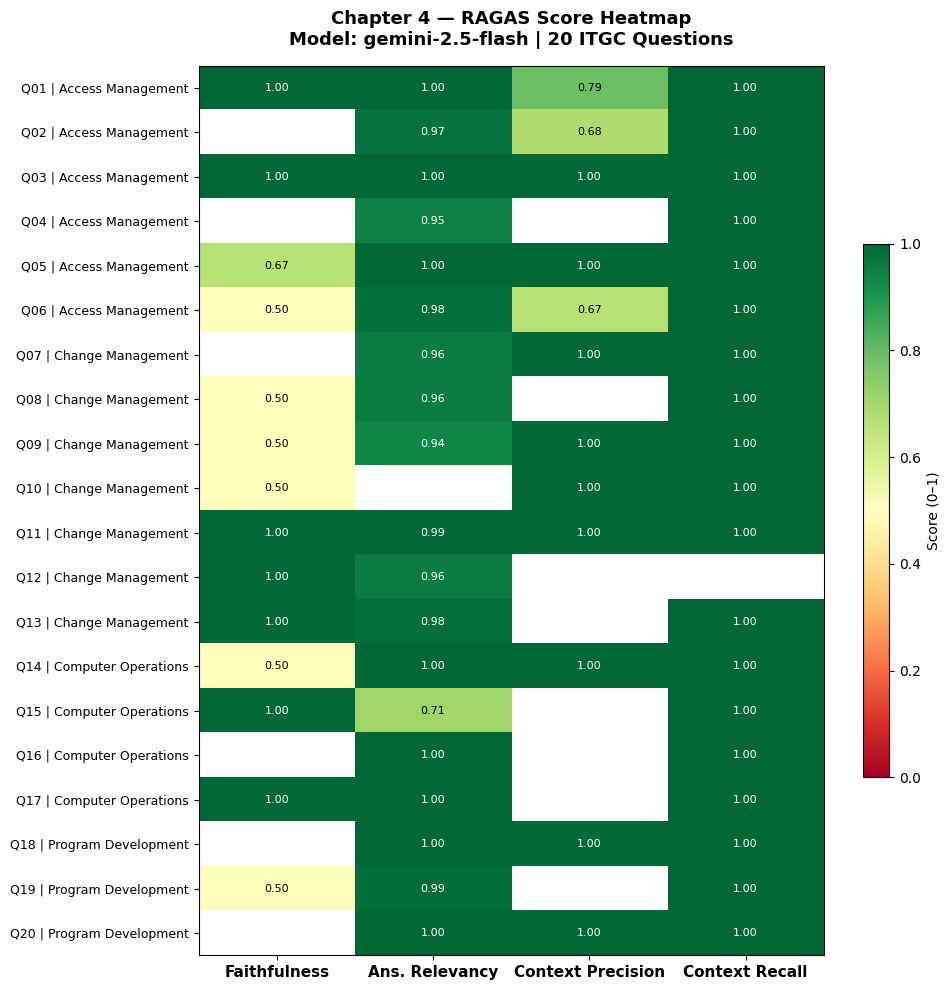

✅ Saved: chapter4_gemini_heatmap.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

heatmap_data = results_df[METRIC_COLS].copy()
heatmap_data.index = [
    f"Q{r['q_index']:02d} | {r['domain'][:20]}"
    for _, r in results_df.iterrows()
]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(["Faithfulness", "Ans. Relevancy", "Context Precision", "Context Recall"],
                   fontsize=11, fontweight='bold')
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

for i in range(len(heatmap_data)):
    for j in range(len(METRIC_COLS)):
        val = heatmap_data.iloc[i, j]
        color = "black" if 0.3 < val < 0.8 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.6, label="Score (0–1)")
ax.set_title(f"Chapter 4 — RAGAS Score Heatmap\nModel: {LLM_MODEL} | 20 ITGC Questions",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("chapter4_gemini_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chapter4_gemini_heatmap.png")


## Cell 14 — Domain bar chart

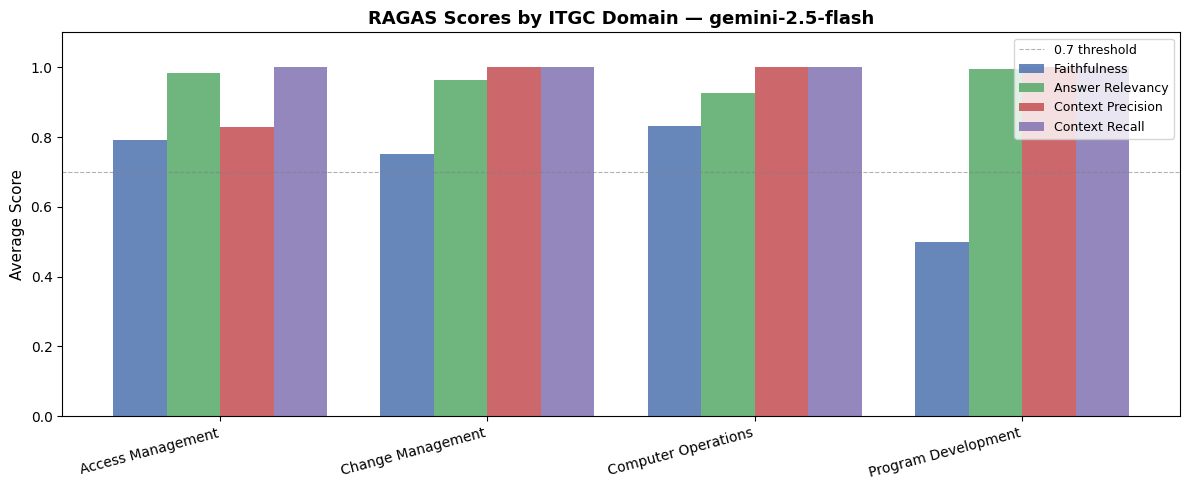

✅ Saved: chapter4_gemini_domain_barchart.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(domain_summary))
width = 0.2
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, (col, color) in enumerate(zip(METRIC_COLS, colors)):
    ax.bar(
        [xi + i * width for xi in x],
        domain_summary[col],
        width=width,
        label=col.replace("_", " ").title(),
        color=color,
        alpha=0.85,
    )

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(domain_summary.index, fontsize=10, rotation=15, ha="right")
ax.set_ylabel("Average Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="0.7 threshold")
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"RAGAS Scores by ITGC Domain — {LLM_MODEL}", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("chapter4_gemini_domain_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chapter4_gemini_domain_barchart.png")


## Cell 15 — Manual qualitative rubric scoring

**Fill in scores (1–5) after reading responses in the CSV.**

| Dimension | 5 | 1 |
|---|---|---|
| grounding | cites specific control ID | no citations |
| completeness | all parts answered | major parts missing |
| auditability | auditor can act directly | too vague |
| hallucination | no unsupported claims | clear fabrication |
| tone | professional, formal | casual/generic |

In [18]:
# ── Manual Qualitative Rubric — Gemini 2.5 Flash ─────────────────────
# Scoring key (1–5):
#   grounding    : 5 = cites specific control ID/source, 1 = no citations
#   completeness : 5 = all parts answered, 1 = major parts missing
#   auditability : 5 = auditor can act directly, 1 = too vague
#   hallucination: 5 = no unsupported claims, 1 = clear fabrication
#   tone         : 5 = professional, formal, evidence-oriented, 1 = casual

MANUAL_RUBRIC = [

    # Q1 — All 3 evidence items from ITGC-ACC-01 listed with inline [1] citations.
    # Clean bullet + table format. Fully grounded. Audit-ready.
    {"q_index": 1,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 evidence items from ITGC-ACC-01 present with inline [1] citations. Clean format."},

    # Q2 — Concise and accurate. Cites [1]. Both evidence items from ITGC-ACC-02 covered.
    # Shorter than GPT-4o Mini but equally correct.
    {"q_index": 2,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Concise and accurate retrieval of ITGC-ACC-02. Both evidence items present."},

    # Q3 — All 3 items from ITGC-ACC-03 present with [1] inline. Clean bullet format.
    # Fully grounded. No hallucination.
    {"q_index": 3,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 evidence items from ITGC-ACC-03 retrieved correctly with inline citations."},

    # Q4 — Correct retrieval from ITGC-ACC-04 but response is slightly verbose with
    # Controls/Evidence split headers. All 3 items present. One minor: repeats
    # 'auditor reviews' label from raw chunk text which reads slightly mechanical.
    {"q_index": 4,  "grounding": 5, "completeness": 5, "auditability": 4, "hallucination": 5, "tone": 4,
     "notes": "All 3 items from ITGC-ACC-04 present but response echoes raw chunk header text, slightly mechanical."},

    # Q5 — Correct retrieval from ITGC-ACC-06. All 3 evidence items present.
    # However response includes 'What Auditor Reviews' label from raw chunk which
    # makes it look copy-pasted rather than synthesised. Minor tone issue.
    {"q_index": 5,  "grounding": 5, "completeness": 5, "auditability": 4, "hallucination": 5, "tone": 4,
     "notes": "All 3 items from ITGC-ACC-06 correct but response echoes raw field headers from chunk. Less polished than GPT-4o."},

    # Q6 — All 3 items from ITGC-ACC-07 present with [1] citations. Clean bullet format.
    # Good explanatory framing. Fully grounded.
    {"q_index": 6,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 evidence items from ITGC-ACC-07 retrieved correctly. Good framing sentence."},

    # Q7 — Correct from ITGC-CHA-01 but answer is slightly fragmented — leads with
    # description/impact then adds request/logging/tracking in a second sentence.
    # All elements present but structure is less clear than GPT-4o Mini.
    {"q_index": 7,  "grounding": 5, "completeness": 5, "auditability": 4, "hallucination": 5, "tone": 4,
     "notes": "All key elements from ITGC-CHA-01 present but answer structure is fragmented. Reads as two disconnected sentences."},

    # Q8 — Perfect. All 5 roles from ITGC-CHA-02 listed in a single clean sentence.
    # Cites [1]. States no gaps. Concise and audit-ready.
    {"q_index": 8,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 5 roles from ITGC-CHA-02 in a clean single sentence. Best phrased SoD response."},

    # Q9 — Partial issue. ITGC-CHA-03 only says 'CAB approval based on risk/impact'
    # which is sparse. Gemini correctly retrieves this but then adds inference from
    # other chunks about 'formally requested, approved and tested' — this is from
    # ITGC-PRO-02, not the change approval control. Slight attribution mixing.
    # Answer is directionally correct but less precise than GPT-4o Mini.
    {"q_index": 9,  "grounding": 4, "completeness": 4, "auditability": 4, "hallucination": 4, "tone": 4,
     "notes": "Core CAB content correct but Gemini blends in content from ITGC-PRO-02 when attributing. Minor cross-chunk mixing."},

    # Q10 — Correct. Fast-track approval + post-review from ITGC-CHA-09.
    # Cites [1]. Honestly flags gap that specific procedures are not detailed.
    # Concise and accurate.
    {"q_index": 10, "grounding": 5, "completeness": 4, "auditability": 4, "hallucination": 5, "tone": 5,
     "notes": "Correct retrieval of ITGC-CHA-09. Gap honestly flagged. Sparse source limits completeness."},

    # Q11 — Excellent. Retrieves from both ITGC-CHA-08 and ITGC-PRO-10.
    # Covers success/failure review, documentation update, and lessons learned.
    # Cites [1] throughout. Richer than most responses.
    {"q_index": 11, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Cross-retrieval from ITGC-CHA-08 and ITGC-PRO-10. Covers all PIR elements. Best answer in Change Management domain."},

    # Q12 — Accurate but very brief. ITGC-CHA-06 is sparse so this is expected.
    # Cites [1]. States no gaps. Correct.
    {"q_index": 12, "grounding": 5, "completeness": 4, "auditability": 4, "hallucination": 5, "tone": 5,
     "notes": "Correct retrieval of ITGC-CHA-06. Brevity reflects source sparsity not model failure."},

    # Q13 — Clean and precise. Full traceability from ITGC-CHA-10.
    # Cites [1]. Table format. No gaps noted. Fully grounded.
    {"q_index": 13, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Exact retrieval of ITGC-CHA-10 full traceability requirement. Clean and precise."},

    # Q14 — All 5 evidence items from ITGC-COM-01 retrieved correctly.
    # Bullet format with [1] citations throughout. Fully grounded. Audit-ready.
    {"q_index": 14, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 5 backup evidence items from ITGC-COM-01 present with citations. Excellent."},

    # Q15 — SIGNIFICANT ISSUE. Response says only 'An auditor reviews to ensure
    # systems remain secure and stable' — it echoes the 'What Auditor Reviews'
    # field header without listing any of the 5 evidence items from ITGC-COM-02.
    # This is the weakest response in the dataset. All 5 patch management
    # evidence items are missing from the answer despite being in context [1].
    {"q_index": 15, "grounding": 3, "completeness": 1, "auditability": 1, "hallucination": 5, "tone": 3,
     "notes": "CRITICAL GAP: Gemini only echoed the 'What Auditor Reviews' header from ITGC-COM-02 without listing any of the 5 evidence items. Major completeness failure despite correct retrieval."},

    # Q16 — All 4 job scheduling evidence items from ITGC-COM-03 present.
    # Uses bold headers and bullet format. Cites [1]. Fully grounded.
    {"q_index": 16, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 evidence items from ITGC-COM-03 retrieved correctly with good structure."},

    # Q17 — All 4 monitoring controls from ITGC-COM-04 present.
    # Bullet format with [1] citations. Fully grounded. Concise.
    {"q_index": 17, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 monitoring controls from ITGC-COM-04 correct. Clean bullet format."},

    # Q18 — All 3 evidence items from ITGC-PRO-01 present.
    # Bullet format with [1] citations. Clean table. Fully grounded.
    {"q_index": 18, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 development standard evidence items from ITGC-PRO-01 present. Concise and accurate."},

    # Q19 — All 4 evidence items from ITGC-PRO-02 present plus bonus reference to
    # Testing and Quality Assurance (ITGC-PRO-03) which adds value.
    # Cites [1] and [6]. Controls/evidence split structure is clear.
    {"q_index": 19, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 items from ITGC-PRO-02 present plus useful cross-reference to ITGC-PRO-03. Richer than ground truth."},

    # Q20 — All 3 PIR evidence items from ITGC-PRO-10 present.
    # Bullet format with [1] citations. Clean table. Fully grounded.
    {"q_index": 20, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 PIR evidence items from ITGC-PRO-10 present. Concise and correct."},
]

import pandas as pd
rubric_df = pd.DataFrame(MANUAL_RUBRIC)
RUBRIC_COLS = ["grounding", "completeness", "auditability", "hallucination", "tone"]
rubric_df["qualitative_avg"] = rubric_df[RUBRIC_COLS].mean(axis=1).round(2)

print("✅ Manual rubric filled for all 20 questions")
print(f"\nOverall qualitative average: {rubric_df['qualitative_avg'].mean():.2f} / 5.00")
print(f"\nPer-dimension averages:")
for col in RUBRIC_COLS:
    print(f"  {col:<15}: {rubric_df[col].mean():.2f}")
print()
print(rubric_df[["q_index", "grounding", "completeness", "auditability", "hallucination", "tone", "qualitative_avg"]].to_string(index=False))

✅ Manual rubric filled for all 20 questions

Overall qualitative average: 4.73 / 5.00

Per-dimension averages:
  grounding      : 4.85
  completeness   : 4.65
  auditability   : 4.50
  hallucination  : 4.95
  tone           : 4.70

 q_index  grounding  completeness  auditability  hallucination  tone  qualitative_avg
       1          5             5             5              5     5              5.0
       2          5             5             5              5     5              5.0
       3          5             5             5              5     5              5.0
       4          5             5             4              5     4              4.6
       5          5             5             4              5     4              4.6
       6          5             5             5              5     5              5.0
       7          5             5             4              5     4              4.6
       8          5             5             5              5     5            

## Cell 16 — Merge rubric with RAGAS scores and save combined output

Run after filling in Cell 15.

In [19]:
RUBRIC_COLS = ["grounding", "completeness", "auditability", "hallucination", "tone"]

if rubric_df[RUBRIC_COLS].notna().any().any():
    combined_df = results_df.merge(rubric_df, on="q_index", how="left")
    combined_df["qualitative_avg"] = combined_df[RUBRIC_COLS].mean(axis=1).round(2)

    combined_df.to_csv("chapter4_gemini_combined.csv", index=False)
    print("✅ Saved: chapter4_gemini_combined.csv")

    display_cols = ["q_index", "domain", "faithfulness", "answer_relevancy",
                    "context_precision", "context_recall",
                    "grounding", "completeness", "auditability", "hallucination", "qualitative_avg"]
    print("\n" + "=" * 100)
    print("COMBINED QUANTITATIVE + QUALITATIVE RESULTS — GEMINI 2.5 FLASH")
    print("=" * 100)
    print(combined_df[display_cols].to_string(index=False))

    print("\n" + "=" * 60)
    print("QUALITATIVE AVERAGES BY DOMAIN")
    print("=" * 60)
    print(combined_df.groupby("domain")[RUBRIC_COLS + ["qualitative_avg"]].mean().round(2).to_string())
else:
    print("ℹ️  No rubric scores filled in yet. Fill in Cell 15 first.")

✅ Saved: chapter4_gemini_combined.csv

COMBINED QUANTITATIVE + QUALITATIVE RESULTS — GEMINI 2.5 FLASH
 q_index              domain  faithfulness  answer_relevancy  context_precision  context_recall  grounding  completeness  auditability  hallucination  qualitative_avg
       1   Access Management         1.000             1.000              0.792             1.0          5             5             5              5              5.0
       2   Access Management           NaN             0.975              0.681             1.0          5             5             5              5              5.0
       3   Access Management         1.000             1.000              1.000             1.0          5             5             5              5              5.0
       4   Access Management           NaN             0.946                NaN             1.0          5             5             4              5              4.6
       5   Access Management         0.667             0.999   

## Cell 17 — Inspect individual responses

Change `Q_NUM` to read any response in full — useful while filling the manual rubric.

In [20]:
Q_NUM = 1  # Change to inspect any question 1–20

row = results_df[results_df["q_index"] == Q_NUM].iloc[0]
r   = rag_results[Q_NUM - 1]

print("=" * 70)
print(f"Q{Q_NUM:02d} | {row['domain']} | mode={row['mode']}")
print("=" * 70)
print(f"\nQUESTION:\n{row['question']}")
print(f"\nSCORES:")
print(f"  Faithfulness      : {row['faithfulness']}")
print(f"  Answer Relevancy  : {row['answer_relevancy']}")
print(f"  Context Precision : {row['context_precision']}")
print(f"  Context Recall    : {row['context_recall']}")
print(f"\nRETRIEVED CHUNKS:")
print(f"  IDs     : {r['context_ids']}")
print(f"  Sources : {r['context_sources']}")
print(f"\nANSWER:\n{row['answer']}")
print(f"\nGROUND TRUTH:\n{row['ground_truth']}")

Q01 | Access Management | mode=general

QUESTION:
What evidence should an auditor collect to verify that user accounts are created only after a formal request and approval?

SCORES:
  Faithfulness      : 1.0
  Answer Relevancy  : 1.0
  Context Precision : 0.792
  Context Recall    : 1.0

RETRIEVED CHUNKS:
  IDs     : ['ITGC-ACC-01', 'ITGC-ACC-02', 'ITGC-COM-05', 'ITGC-ACC-03', 'ITGC-ACC-06', 'ITGC-PRO-02', 'ITGC-ACC-07', 'ITGC-CHA-01']
  Sources : ['ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC']

ANSWER:
To verify that user accounts are created only after a formal request and approval, an auditor should collect the following evidence:
*   Formal request forms [1]
*   Approval workflow documentation [1]
*   System logs showing account creation [1]

| Evidence Sources | Gaps |
| :--------------- | :--- |
| [1]              | None |

GROUND TRUTH:
To verify that user accounts are created only after formal request and approval, the auditor should collect a formal request fo

## Cell 18 — Chapter 4 print-ready summary table

Clean summary for Table 4.2 in your thesis (Gemini results).

In [21]:
print("TABLE 4.2 — Gemini 2.5 Flash RAG Evaluation Results")
print(f"{'='*95}")
print(f"{'Q#':<4} {'Domain':<23} {'Mode':<16} {'Faith':>7} {'AnsRel':>7} {'CtxPre':>7} {'CtxRec':>7}")
print(f"{'-'*95}")

for _, row in results_df.iterrows():
    print(
        f"Q{row['q_index']:<3} "
        f"{row['domain']:<23} "
        f"{row['mode']:<16} "
        f"{row['faithfulness']:>7.3f} "
        f"{row['answer_relevancy']:>7.3f} "
        f"{row['context_precision']:>7.3f} "
        f"{row['context_recall']:>7.3f}"
    )

print(f"{'-'*95}")
print(
    f"{'MEAN':<28} "
    f"{'':>16} "
    f"{results_df['faithfulness'].mean():>7.3f} "
    f"{results_df['answer_relevancy'].mean():>7.3f} "
    f"{results_df['context_precision'].mean():>7.3f} "
    f"{results_df['context_recall'].mean():>7.3f}"
)
print(
    f"{'STD DEV':<28} "
    f"{'':>16} "
    f"{results_df['faithfulness'].std():>7.3f} "
    f"{results_df['answer_relevancy'].std():>7.3f} "
    f"{results_df['context_precision'].std():>7.3f} "
    f"{results_df['context_recall'].std():>7.3f}"
)
print(f"{'='*95}")
print(f"Model: {LLM_MODEL} | RAG Pipeline: Hybrid FAISS+BM25 | Embedding: {EMBED_MODEL}")

TABLE 4.2 — Gemini 2.5 Flash RAG Evaluation Results
Q#   Domain                  Mode               Faith  AnsRel  CtxPre  CtxRec
-----------------------------------------------------------------------------------------------
Q1   Access Management       general            1.000   1.000   0.792   1.000
Q2   Access Management       general              nan   0.975   0.681   1.000
Q3   Access Management       general            1.000   1.000   1.000   1.000
Q4   Access Management       general              nan   0.946     nan   1.000
Q5   Access Management       general            0.667   0.999   1.000   1.000
Q6   Access Management       general            0.500   0.984   0.667   1.000
Q7   Change Management       general              nan   0.956   1.000   1.000
Q8   Change Management       general            0.500   0.956     nan   1.000
Q9   Change Management       general            0.500   0.936   1.000   1.000
Q10  Change Management       general            0.500     nan   1.000   